In [2]:
import random
random.seed(0)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
#Daily double bet amount
#https://en.wikipedia.org/wiki/Strategies_and_skills_of_Jeopardy!_champions
#https://neptune.ai/blog/monte-carlo-simulation
#https://arxiv.org/pdf/1402.0571.pdf
#dd equity curves on right/wrong
#confidence of right answer creates different curves and optimal bets
#condition bet amount on confidence of answering question correctly
#higher confidence = high bet amount
# optimal bet | .75 confidence -> bet max
# optimal bet | .35 confidence -> bet min

In [4]:
def get_next_clue(board):
  """Return the next clue on the board. Default selection is next in ordered list"""
  return board.pop(0)

def score_clue(scores, clue):
  """Return the updated scores after the clue is scored"""
  players = [0,1,2]
  i = random.choice(players) #0,1,2
  scores[i] += clue
  return scores

def play_game(scores, player, board, wager, confidence = 1):
  """Play game from point where a player selects the daily double with randomized wager"""
  right = answer_correct(confidence)
  if(right):
    scores[player] += wager
  else:
    scores[player] -= wager
  for clue in board:
    clue = get_next_clue(board)
    score_clue(scores,clue)
  return scores

def answer_correct(p):
  """Return the result of a single bernoulli trial with probability p"""
  return 1 if random.random() < p else 0

In [5]:
scores = [19400,6400,17200]
board = [2000,800,1200,1200,400,1600,2000,800,800,800,400,400,400]
player = 2

In [6]:
results = []
num_trials = 10000000
for i in range(num_trials):

  scores = [19400,6400,17200]
  board = [2000,800,1200,1200,400,1600,2000,800,800,800,400,400,400]
  conf_thresholds = [.35,.45,.55,.65,.75]
  player = 2
  #range doesn't include end value by default
  #all clue values and possible scores left are multiples of 400
  wager = random.choice(range(0,scores[player]+1,400))
  confidence = random.choice(conf_thresholds)
  result = play_game(scores, player, board, wager, confidence)
  results.append({
      "game": i,
      "wager": wager,
      "confidence": confidence,
      "lead": scores[player] > sorted(scores,reverse = True)[1],
      "lock": scores[player] >= 2*(sorted(scores, reverse = True)[1])
  })
df = pd.DataFrame(results)


In [12]:
df.groupby(["wager","confidence"])["lead"].count()


wager  confidence
0      0.35          45702
       0.45          45527
       0.55          45037
       0.65          45629
       0.75          45856
                     ...  
17200  0.35          45118
       0.45          45357
       0.55          45398
       0.65          45431
       0.75          45337
Name: lead, Length: 220, dtype: int64

In [11]:
#plot average lead pct by wager and confidence rather than error bars
summary_lead = df.groupby(["wager","confidence"])["lead"].mean()
df_mean_lead = summary_lead.to_frame().reset_index()
df_mean_lead

,wager,confidence,lead
0,0,0.35,0.242922
1,0,0.45,0.244558
2,0,0.55,0.242845
3,0,0.65,0.243332
4,0,0.75,0.245944
...,...,...,...
215,17200,0.35,0.348309
216,17200,0.45,0.448112
217,17200,0.55,0.546918
218,17200,0.65,0.648104


In [8]:
summary_lock = df.groupby(["wager","confidence"])["lock"].mean()
df_mean_lock = summary_lock.to_frame().reset_index()
df_mean_lock

,wager,confidence,lock
0,0,0.35,0.000000
1,0,0.45,0.000000
2,0,0.55,0.000000
3,0,0.65,0.000000
4,0,0.75,0.000000
...,...,...,...
215,17200,0.35,0.019926
216,17200,0.45,0.025729
217,17200,0.55,0.032028
218,17200,0.65,0.035725


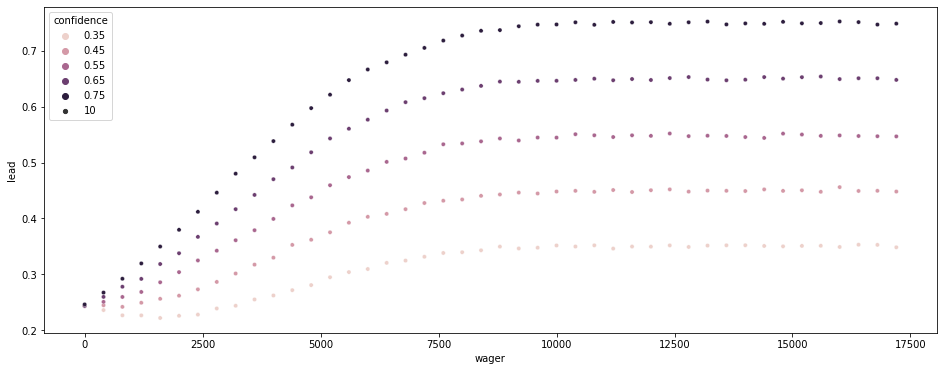

In [9]:
plt.figure(figsize=(16, 6))
sns.scatterplot(data = df_mean_lead, x = "wager", y = "lead", hue ="confidence", size = 10)


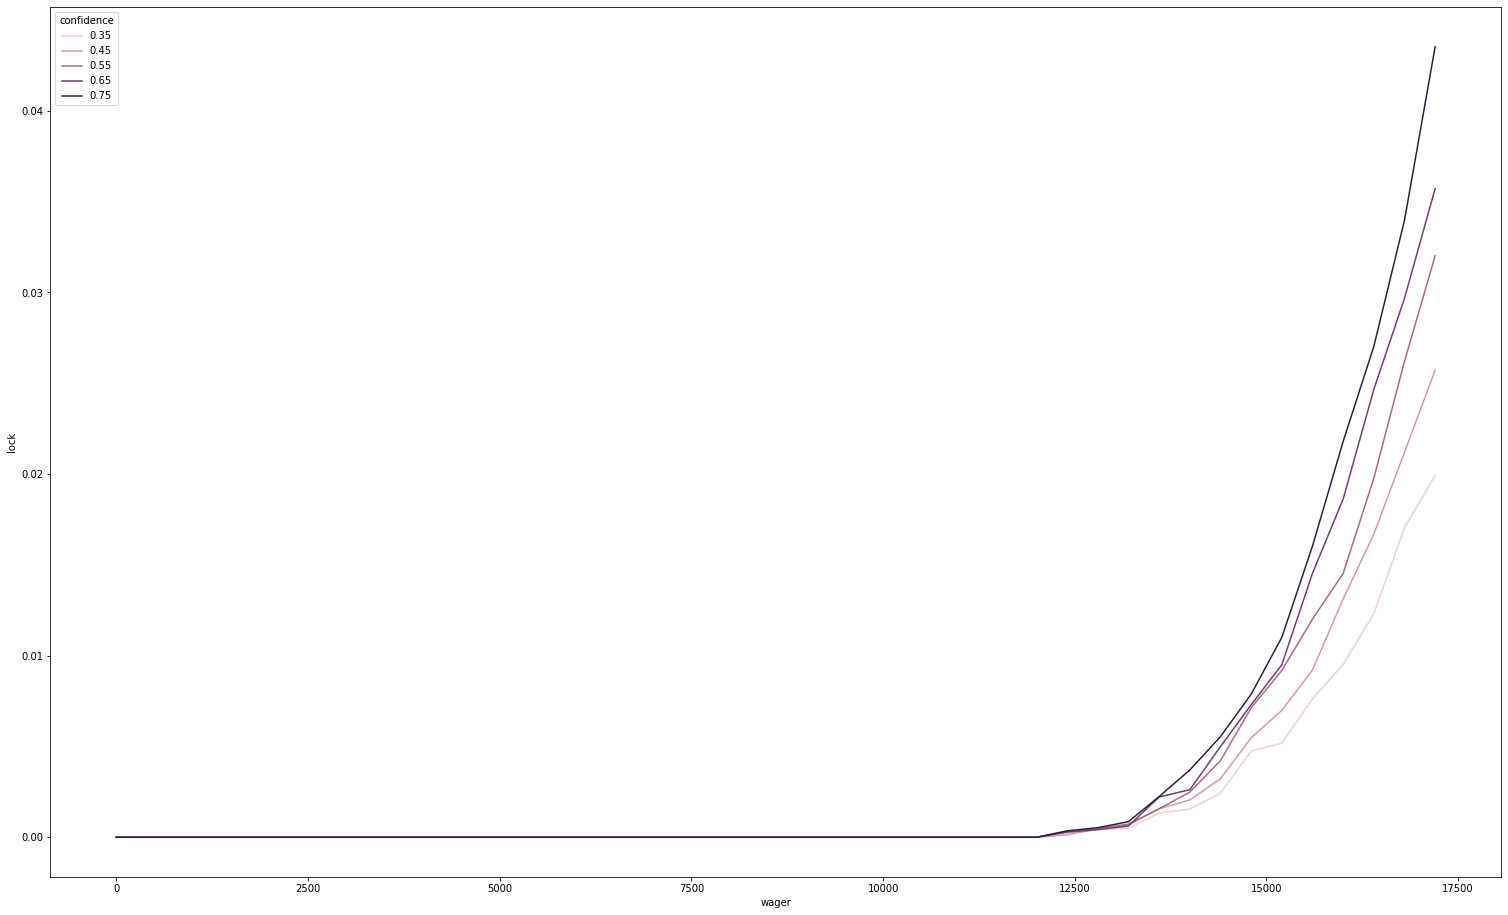

In [10]:
plt.figure(figsize=(26, 16))
sns.lineplot(data = df_mean_lock, x = "wager", y = "lock",hue ="confidence")